# quiz 1 基礎


In [1]:
import pandas as pd

In [2]:
from other_code.quiz1 import data_segment, feature_scale, train_model, evaluate_model, save_confusion_matrix

val_ratio = 0.3

dataset = pd.read_csv("./dataset/data.csv")
X_train, X_val, y_train, y_val = data_segment(dataset,val_ratio)
X_train_scaled, X_val_scaled = feature_scale(X_train, X_val)

model = train_model(X_train_scaled, y_train)

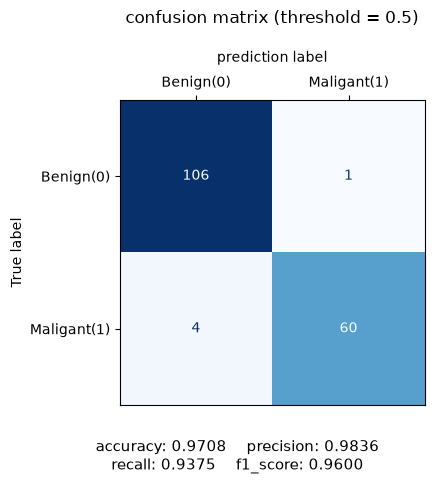

In [3]:
threshold = 0.5

cm, scores = evaluate_model(model, X_val_scaled, y_val, threshold)
save_confusion_matrix(cm, scores, save_path=f"./result/quiz1_1/confusion_matrix_{threshold}.png", threshold=threshold)

# quiz 1 進階

In [4]:
from other_code.quiz1 import train_random_forset, evaluate_model, save_confusion_matrix

rf_model = train_random_forset(X_train_scaled, y_train)

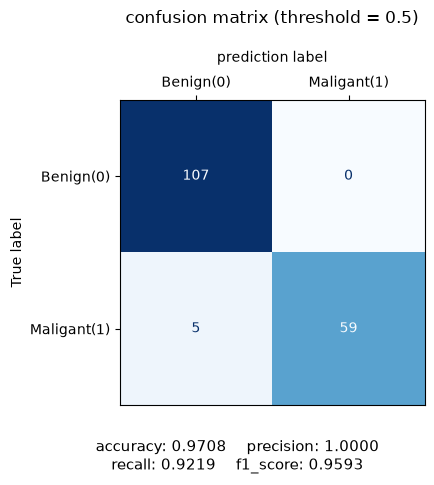

In [5]:
rf_cm, rf_scores = evaluate_model(rf_model, X_val_scaled, y_val, threshold)
save_confusion_matrix(rf_cm, rf_scores, save_path=f"./result/quiz1_2/confusion_matrix_{threshold}.png", threshold=threshold)

# quiz 2 基礎

In [6]:
import pandas as pd
import torch
from other_code.quiz2 import *

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用裝置：{device}")

使用裝置：cuda


In [8]:
Batch_size = 64

data = pd.read_csv("./dataset/UCI_Credit_Card.csv")
X_train, X_val, X_test, y_train, y_val, y_test = data_segment(data)
X_train_preprocessed, X_val_preprocessed, X_test_preprocessed, peocessor = feature_preprocess(X_train, X_val, X_test)

train_loader = create_dataloader(X_train_preprocessed, y_train, batch_size=Batch_size, shuffle=True)
val_loader = create_dataloader(X_val_preprocessed, y_val, batch_size=Batch_size, shuffle=False)
test_loader = create_dataloader(X_test_preprocessed, y_test, batch_size=Batch_size, shuffle=False)

input_dim = X_train_preprocessed.shape[1]

In [9]:
Learning_rate = 0.01
Epoch = 50

In [10]:
model = MLP(input_dim).to(device)
model, history = train_model(model, train_loader, val_loader, device, epochs=Epoch, learning_rate=Learning_rate, threshold=0.5)

epoch 1/50 | train loss: 0.4517, F1: 0.4359 | val loss: 0.4377, val f1: 0.4784
epoch 2/50 | train loss: 0.4365, F1: 0.4765 | val loss: 0.4423, val f1: 0.4304
epoch 3/50 | train loss: 0.4316, F1: 0.4721 | val loss: 0.4411, val f1: 0.4636
epoch 4/50 | train loss: 0.4285, F1: 0.4752 | val loss: 0.4343, val f1: 0.4590
epoch 5/50 | train loss: 0.4280, F1: 0.4727 | val loss: 0.4368, val f1: 0.4514
epoch 6/50 | train loss: 0.4265, F1: 0.4825 | val loss: 0.4356, val f1: 0.4334
epoch 7/50 | train loss: 0.4230, F1: 0.4819 | val loss: 0.4359, val f1: 0.4528
epoch 8/50 | train loss: 0.4216, F1: 0.4860 | val loss: 0.4369, val f1: 0.4582
epoch 9/50 | train loss: 0.4200, F1: 0.4902 | val loss: 0.4425, val f1: 0.4547
epoch 10/50 | train loss: 0.4193, F1: 0.4891 | val loss: 0.4370, val f1: 0.4597
epoch 11/50 | train loss: 0.4173, F1: 0.4984 | val loss: 0.4422, val f1: 0.4609
epoch 12/50 | train loss: 0.4156, F1: 0.5038 | val loss: 0.4511, val f1: 0.4562
epoch 13/50 | train loss: 0.4160, F1: 0.4973 | va

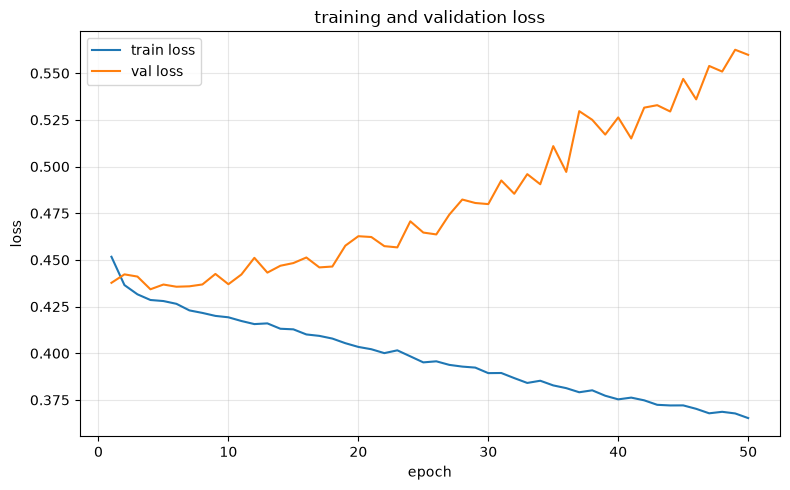

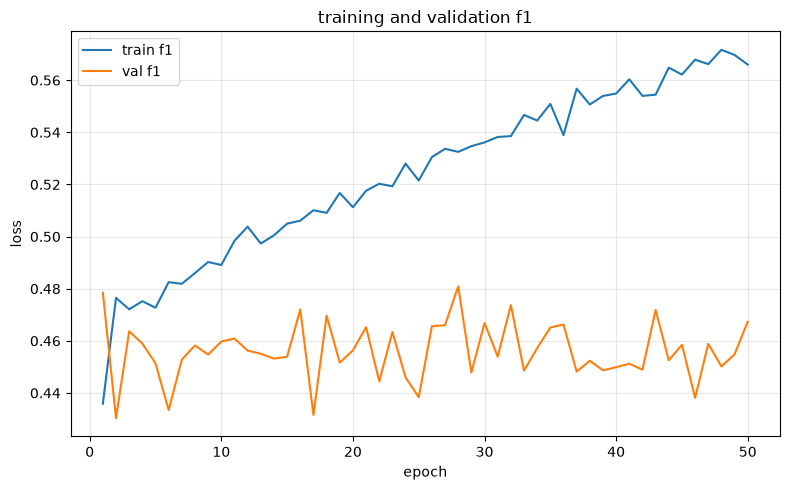

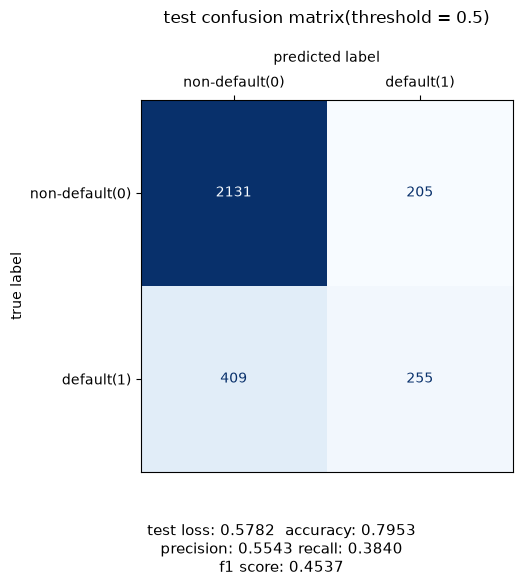

In [11]:
test_scores, test_cm = evaluate_model(model, test_loader, device, threshold=0.5)
save_result_plots(history=history, test_scores=test_scores, test_cm=test_cm, save_dir="./result/quiz2_1", prefix="quiz2_1", threshold=0.5)

# quiz 2 進階


In [12]:
Learning_rate = 0.0001
Epoch = 100
Dropout = 0.2
torch.manual_seed(42)

In [13]:
model_v2 = MLP_v2(input_dim, dropout=Dropout).to(device)
model_v2, history = train_model_v2(model_v2, train_loader, val_loader, device,
                                   epochs=Epoch, learning_rate=Learning_rate, threshold=0.5)

epoch 1/100 | train loss: 0.5636, F1: 0.0000 | val loss: 0.4845, val f1: 0.0000
epoch 2/100 | train loss: 0.4709, F1: 0.0316 | val loss: 0.4537, val f1: 0.2578
epoch 3/100 | train loss: 0.4519, F1: 0.3986 | val loss: 0.4436, val f1: 0.4439
epoch 4/100 | train loss: 0.4437, F1: 0.4765 | val loss: 0.4401, val f1: 0.4774
epoch 5/100 | train loss: 0.4397, F1: 0.4968 | val loss: 0.4384, val f1: 0.4857
epoch 6/100 | train loss: 0.4384, F1: 0.5001 | val loss: 0.4380, val f1: 0.4892
epoch 7/100 | train loss: 0.4372, F1: 0.5028 | val loss: 0.4372, val f1: 0.4959
epoch 8/100 | train loss: 0.4365, F1: 0.5015 | val loss: 0.4366, val f1: 0.4872
epoch 9/100 | train loss: 0.4344, F1: 0.5014 | val loss: 0.4360, val f1: 0.4849
epoch 10/100 | train loss: 0.4326, F1: 0.4969 | val loss: 0.4354, val f1: 0.4847
epoch 11/100 | train loss: 0.4318, F1: 0.4951 | val loss: 0.4353, val f1: 0.4832
epoch 12/100 | train loss: 0.4323, F1: 0.4985 | val loss: 0.4346, val f1: 0.4846
epoch 13/100 | train loss: 0.4320, F1

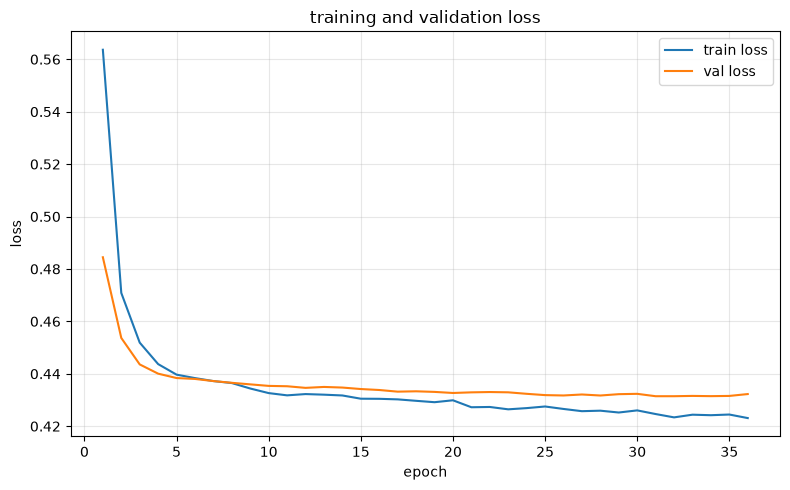

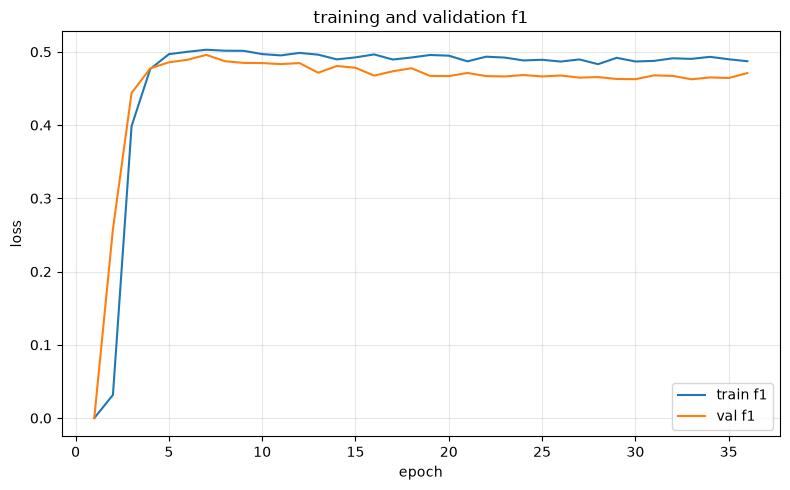

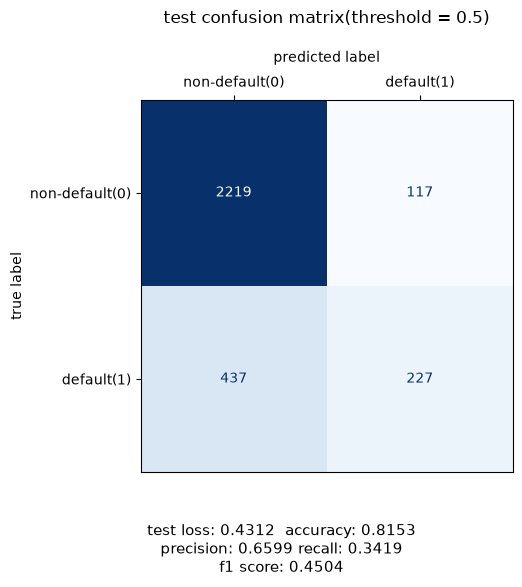

In [14]:
test_scores, test_cm = evaluate_model(model_v2, test_loader, device, threshold=0.5)
save_result_plots(history=history, test_scores=test_scores, test_cm=test_cm, save_dir="./result/quiz2_2", prefix="quiz2_2", threshold=0.5)

# quiz 3 基礎

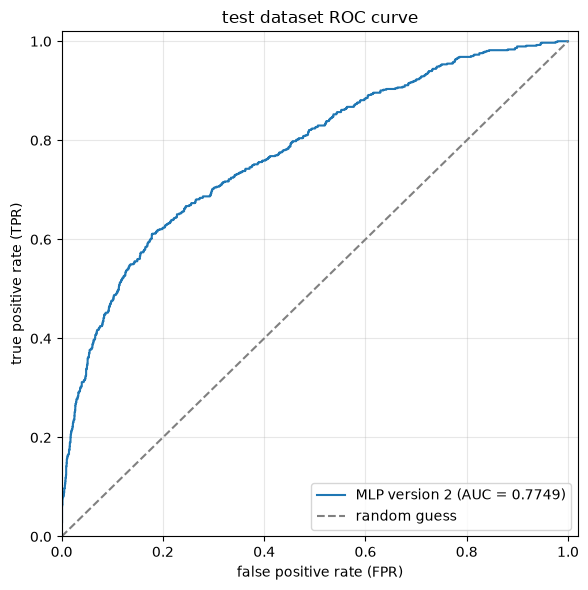

test AUC: 0.7749


In [15]:
from other_code.quiz3 import *

test_auc = save_roc_curve(model=model_v2, test_loader=test_loader, device=device, save_path="./result/quiz3_1/test_roc_curve.png")
print(f"test AUC: {test_auc:.4f}")

# quiz 3 進階

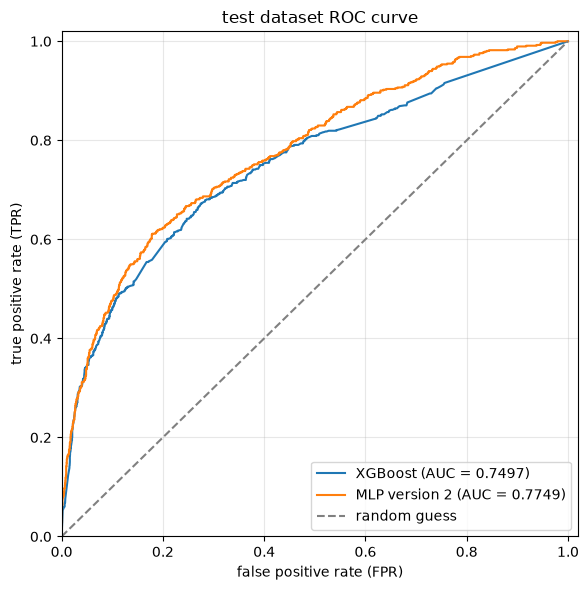

MLP v2 test auc: 0.7749
XGBoost test auc: 0.7497


In [16]:
xgb_model = train_xgboost(X_train=X_train_preprocessed, y_train=y_train, learning_rate=Learning_rate)
auc_curve = save_roc_xgboost(mlp=model_v2, xgb=xgb_model, test_loader=test_loader, device=device, 
                            save_path="./result/quiz3_2/roc_curve_comparison.png")

for name, value in auc_curve.items():
    print(f"{name} test auc: {value:.4f}")